# Heading
Ziel ist die Berechnung der Laufrichtung aus den Daten des Magnetometers.

## Import statements

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import math
from scipy.spatial.transform import Rotation

## Daten einlesen

In [2]:
db_path = "../data/emi_nav.db"
conn = sqlite3.connect(db_path)

run_id =  "R3"

df_mag = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'mag'
        ORDER BY timestamp_ms
    """, conn)
df_mag["t_sec"] = (df_mag["timestamp_ms"] - df_mag["timestamp_ms"].min()) / 1000

df_accel = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'accel'
        ORDER BY timestamp_ms
    """, conn)

df_accel["t_sec"] = (df_accel["timestamp_ms"] - df_accel["timestamp_ms"].min()) / 1000

df_gyro = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'gyro'
        ORDER BY timestamp_ms
    """, conn)

df_gyro["t_sec"] = (df_gyro["timestamp_ms"] - df_gyro["timestamp_ms"].min()) / 1000

df_processed = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'imu_processed'
        ORDER BY timestamp_ms
    """, conn)

df_processed["t_sec"] = (df_processed["timestamp_ms"] - df_processed["timestamp_ms"].min()) / 1000

df_steps = pd.read_sql(
    f"""
        SELECT timestamp_ms FROM steps
        WHERE run_id = '{run_id}'
        ORDER BY timestamp_ms
    """, conn)

df_steps["t_sec"] = (df_steps["timestamp_ms"] - df_steps["timestamp_ms"].min()) / 1000

## Integration der Gyro-Daten

Im ersten Schritt werden die drei Achsen des Gyro integriert um die Orientierung des Smartphones zu jedem Zeitpunkt zu erhalten. <br>
Der Gyro misst rad/s, also die Winkelgeschwindigkeit. Durch einfache Integration erhalten wir die Orientierung. Diese Messwerte unterliegen jedoch zufälligem Rauschen. Durch die Integration akkumuliert sich der Fehler, wir beobachten einen sogenannten Drift. Dieser muss später durch Fusion mit dem Magnetometer ausgeglichen werden.<br>

In [4]:
np.linalg.norm(df_accel[['x', 'y', 'z']].iloc[5].values)

10.813883608393517

In [5]:
def integrate_gyro(row):
    """
    Gyro measures the rotational velocity in rad/s. 
    integrate_gyro integrates the measured values into actual orientations in rad.
    :param row - One row of the dataframe containing at least the columns x, y, z and dt.
    :returns - The integrated orientations in rad.
    """
    return row[['x', 'y', 'z']] * row['dt']

def calculate_roll_pitch_yaw(df):
    """
    df contains the integrated orientation as euler orientation in the phones reference frame.
    calculate_roll_pitch_yaw converts the orientation into a world-frame orientation with roll, pitch and yaw values. 
    :param df - The dataframe containg the columns dx, dy and dz.
    :returns - The dataframe with columns roll, pitch and yaw applied.
    """
    omega = df[['dx', 'dy', 'dz']].copy().to_numpy(dtype=float) # Convert dataframe columns into a Nx3 matrix, N being the number or measurements.

    # Define initial Orientation
    orientation_current = R.identity()

    quaternions = np.zeros((len(omega), 4))   # Nx4 matrix representing the orientation as quaternions
    quaternions[0] = orientation_current.as_quat()

    # Iterate over each measurement (row) and continue conversion to quaternions
    for i in range(1, len(omega)):
        dq = R.from_rotvec(omega[i])

        orientation_current = orientation_current * dq

        quaternions[i] = orientation_current.as_quat()

    # Convert quaternions into roll, pitch and yaw
    euler_deg = R.from_quat(quaternions).as_euler('xyz', degrees=True)

    result = pd.DataFrame({
        'roll_deg': euler_deg[:, 0],
        'pitch_deg': euler_deg[:, 1],
        'yaw_deg': euler_deg[:, 2],
    })

    return result

In [6]:
df_gyro['dt'] = df_gyro['t_sec'].diff().fillna(0.0)
df_gyro[['dx', 'dy', 'dz']] = df_gyro.apply(integrate_gyro, axis=1)
df_gyro[['roll', 'pitch', 'yaw']] = calculate_roll_pitch_yaw(df_gyro)
df_gyro

,timestamp_ms,x,y,z,t_sec,dt,dx,dy,dz,roll,pitch,yaw
0,1781615346887,-0.260229,-0.193033,0.013439,0.000,0.000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000
1,1781615346893,-0.260229,-0.193033,0.013439,0.006,0.006,-0.001561,-0.001158,0.000081,-0.089463,-0.066356,0.004672
2,1781615346900,-0.260229,-0.193033,0.013439,0.013,0.007,-0.001822,-0.001351,0.000094,-0.193843,-0.143763,0.010253
3,1781615346908,-0.260229,-0.193033,0.013439,0.021,0.008,-0.002082,-0.001544,0.000108,-0.313144,-0.232215,0.016805
4,1781615346916,-0.260229,-0.193033,0.013439,0.029,0.008,-0.002082,-0.001544,0.000108,-0.432457,-0.320653,0.023540
...,...,...,...,...,...,...,...,...,...,...,...,...
25624,1781615551981,-0.300546,-0.709825,0.359189,205.094,0.009,-0.002705,-0.006388,0.003233,-92.825395,-24.134225,-97.243245
25625,1781615551988,-0.250455,-0.758695,0.299324,205.101,0.007,-0.001753,-0.005311,0.002095,-93.058816,-23.998714,-96.917173
25626,1781615551996,-0.237016,-0.753808,0.260229,205.109,0.008,-0.001896,-0.006030,0.002082,-93.317602,-23.860402,-96.547004
25627,1781615552004,-0.232129,-0.728151,0.211359,205.117,0.008,-0.001857,-0.005825,0.001691,-93.568391,-23.743652,-96.189235


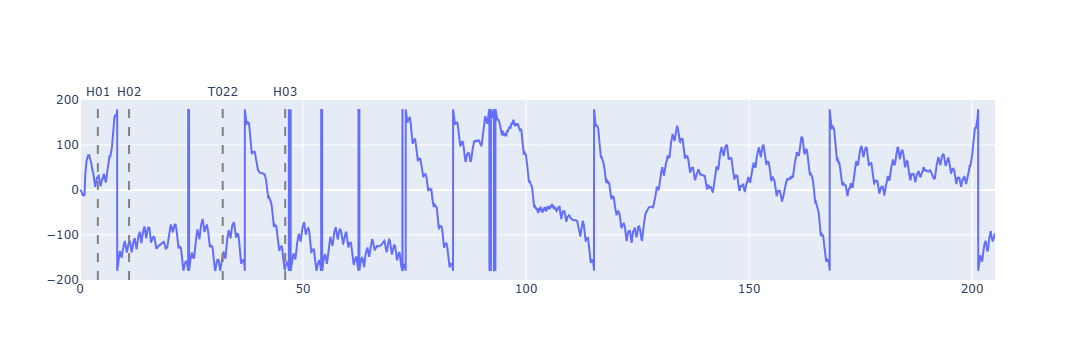

In [7]:
fig=go.Figure()

"""fig.add_trace(
    go.Scatter(
        x=df_processed['t_sec'],
        y=df_processed['x'],
        mode='lines',
        name='Yaw_fused'
    )
)"""

fig.add_trace(
    go.Scatter(
        x=df_gyro['t_sec'],
        y=df_gyro['yaw'],
        mode='lines',
        name='Yaw'
    )
)

markers_r1 = {4: 'H01', 11: 'H02', 32: 'T022', 46: 'H03'}
markers_r2 = {18: 'H03', 52: 'H13', 78: 'H12', 93: 'H11', 116: 'H01', 123: 'H02'}

for x, label in markers_r1.items():
    fig.add_vline(
        x=x,
        line_dash='dash',
        line_color='gray',
        annotation_text=label,
        annotation_position='top'
    )
    
fig.show()

In [8]:
df_gyro['heading_rad'] = df_gyro.yaw / 180 * math.pi
df_gyro.head(5)

,timestamp_ms,x,y,z,t_sec,dt,dx,dy,dz,roll,pitch,yaw,heading_rad
0,1781615346887,-0.260229,-0.193033,0.013439,0.000,0.000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1781615346893,-0.260229,-0.193033,0.013439,0.006,0.006,-0.001561,-0.001158,0.000081,-0.089463,-0.066356,0.004672,0.000082
2,1781615346900,-0.260229,-0.193033,0.013439,0.013,0.007,-0.001822,-0.001351,0.000094,-0.193843,-0.143763,0.010253,0.000179
3,1781615346908,-0.260229,-0.193033,0.013439,0.021,0.008,-0.002082,-0.001544,0.000108,-0.313144,-0.232215,0.016805,0.000293
4,1781615346916,-0.260229,-0.193033,0.013439,0.029,0.008,-0.002082,-0.001544,0.000108,-0.432457,-0.320653,0.023540,0.000411


## Sensorfusing aus Gyro und Mag

In [3]:
df_mag = pd.merge_asof(
    df_mag,
    df_gyro[['t_sec', 'heading_rad']],
    on='t_sec',
    direction='nearest'
)
df_mag

KeyError: "['heading_rad'] not in index"

Bezüglich der Orientierung des Smartphones können grundsätzlich verschiedene Sensordaten verwendet werden. Das Accelerometer liefert Beschleunigungsdaten in verschiedene Achsen. Befindet sich das Smartphone im Stillstand kann man von diesen mit Hilfe der bekannten Gravitationsbeschleunigung von $9.81\frac{m}{s^2}$ die Orientierung des Geräts ableiten. Da sich der Benutzer im gegebenen Szenario meist in Bewegung befindet, werden diese hier nicht genutzt.<br>
Das Gyroskop misst Rotationsgeschwindigkeiten um die drei Achsen des Smartphones in $\frac{rad}{s}$. Das Gyroskop unterliegt einem festen Drift von **TODO: messen**. Dieser wurde bestimmt, indem das Smartphone über einen Zeitraum von **X** Minuten nicht bewegt wurde. Die während dieses Zeitraums gemessenen Rotationsgeschwindigkeiten wurden gemittelt und werden als Bias auf zukünftige Messwerte zur Korrektur angewandt. Integriert man die Messwerte des Gyroskops erhält man die absolute Orientierung des Geräts. Über kurze Zeiträume ist diese relativ zur vorherigen Orientierung sehr genau **TODO Wie genau?**. Nichtsdestotrotz unterliegen die Messungen zufälligen Fehlern, dem Messrauschen. Dieses beträgt beim vorliegenden Sensor **X**. Durch die Integration akkumuliert sich dieser Fehler und führt zum sogenannten Drift der Orientierung. <br>
Um diesen Drift auszugleichen kann man die Messwerte mit einem Sensor fusionieren, welcher keine Rotationsgeschwindigkeiten liefert, sondern absolute Rotationen. Möglich wäre die Verwendung des Accelerometers, zu Zeitpunkten, an denen das Smartphone still steht. Besser geeignet ist das Magnetometer, welches zu jedem Zeitpunkt verwendbare Messwerte liefert. Diese sind auf kurze Zeit deutlich ungenauer, als die des Gyroskops **TODO Wie ungenau?**. Der Vorteil liegt darin, dass absolute Messwerte vorliegen, die nicht integriert werden müssen. Dadurch sind die Messwerte immer gleich ungenau und unterliegen keinem Drift. Sie können daher als Korrektur genutzt werden.<br><br>
Zur Fusionierung wird ein Kalman-Filter verwendet. 

$x_k=[\theta]$

Dieser besteht aus einem Prädiktionsschritt und einem Updateschritt. Im Prädiktionsschritt wird der der State $x_k$ gemeinsam mit der Unsicherheitsmatrix $p_k$ durch die Sensormessung des Gyroskop $u_k$ geupdatet. 

$x_{k+1}=x_k+u_k*\delta t$<br>
$p_{k+1}=p_k+R$

$u_k$ ist dabei der Messwert des Gyroskop, $R$ repräsentiert das Systemrauschen. Die Unsicherheit steigt mit aufeinanderfolgenden Gyroskop-Messungen immer weiter an, bis durch das Magnetometer eine Messung $z_k$ vorliegt. Diese "zieht" im Update-Schritt den abgedrifteten State zurück zum wahren Wert. Hierfür wird zunächst das sogenannte Kalman-Gain $K_k$ zum Zeitpunkt $k$ berechnet.

$K_k=\frac{p_k}{p_k+Q}$

Anschließend können der State $x_{k+1}$ und die Unsicherheit $p_{k+1}$ aktualisiert werden.

$x_{l+1}=x_k+K_k(z_k-x_k)$<br>
$p_{k+1}=K_k*p_k$

In [21]:
def wrap(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def _yaw_free(orientation):
    """Yaw aus der Orientierung entfernen -> nur Roll/Pitch (zum Leveln des Mag)."""
    yaw = orientation.as_euler('ZYX')[0]
    return Rotation.from_euler('z', -yaw) * orientation


def prediction(x_k, p_k, u_k, dt, R):
    """
    Updates the system state and uncertainty by a measurement u_k.
    :param x_k: The current system state as scalar in rad.
    :param p_k: The current uncertainty as scalar.
    :param u_k: A sensor-measurement in [rad/s] representing the change in orientation.
    :param dt: The time difference since the last measurement.
    :param R: The covariance matrix representing the system noise.
    :returns The updated state x_k+1 and uncertainty p_k+1.
    """
    x_k = wrap(x_k + u_k * dt)
    p_k = p_k + R * dt
    return x_k, p_k


def update(x_k, p_k, z_k, Q):
    """
    Corrects the system state by a measurement input z_k.
    :param x_k: The current system state as scalar in rad.
    :param p_k: The current uncertainty as scalar.
    :param z_k: A sensor measurement representing the current orientation in rad.
    :param Q: The covariance matrix representing the measurement noise.
    :returns The updated state x_k+1 and uncertainty p_k+1.
    """
    kalman_gain = p_k / (p_k + Q)
    x_k = wrap(x_k + kalman_gain * wrap(z_k - x_k))
    p_k = (1 - kalman_gain) * p_k
    return x_k, p_k


def fuse_heading(df_gyro, df_mag, R=1e-3, Q=np.radians(15.0) ** 2):
    """
    Utilizes a simple kalman-filter to fuse the gyroscope- and magnetometer-readings.
    :param df_gyro: A dataframe representing the gyroscope readings. Contains at least following columns: [x, y, z, dt, t_sec].
    :param df_mag: A dataframe representing the magnetometer readings. Contains at least following columns: [x, y, z, t_sec].
    :param R: A scalar representing the system-noise.
    :param Q: A scalar representing the measurement-noise.
    """
    # Initialize gyro
    angular_velocity = df_gyro[['x', 'y', 'z']].to_numpy(float)
    time_gyro = df_gyro['t_sec'].to_numpy(float)
    time_step = np.diff(df_gyro.t_sec, prepend=0.0)#df_gyro['dt'].to_numpy(float)
    # Initialize magnetometer
    mag_field = df_mag[['x', 'y', 'z']].to_numpy(float)
    time_mag = df_mag['t_sec'].to_numpy(float)
    
    orientation = Rotation.identity()  # Initialize orientation
    heading = 0.0                      # Initial heading
    heading_variance = np.radians(180.0) ** 2
    heading_out = np.empty(len(time_gyro))
    mag_heading = np.full(len(time_mag), np.nan)
    mag_index = 0

    # Iterate over each gyro reading
    for i in range(len(time_gyro)):
        # Prediction-Step
        if i > 0:
            orientation = orientation * Rotation.from_rotvec(angular_velocity[i] * time_step[i])
            yaw_rate_world = orientation.apply(angular_velocity[i])[2]
            heading, heading_variance = prediction(
                heading, heading_variance, yaw_rate_world, time_step[i], R)
        # Update-Step
        while mag_index < len(time_mag) and time_mag[mag_index] <= time_gyro[i]:
            mag_leveled = _yaw_free(orientation).apply(mag_field[mag_index])
            measured_heading = -np.arctan2(mag_leveled[1], mag_leveled[0])   # CCW von magnetisch Nord
            mag_heading[mag_index] = measured_heading
            heading, heading_variance = update(
                heading, heading_variance, measured_heading, Q)
            mag_index += 1
        heading_out[i] = heading

    df_out = pd.DataFrame({'t_sec': time_gyro, 'heading_deg': np.degrees(heading_out)})
    df_mag_out = pd.DataFrame({'t_sec': time_mag, 'heading_mag_deg': np.degrees(mag_heading)})
    return df_out, df_mag_out

In [18]:
np.diff(df_gyro.t_sec)

array([0.006, 0.007, 0.008, ..., 0.008, 0.008, 0.008])

In [19]:
r0 = Rotation.from_euler('xyz', [0.0, 0.0, 0.0])

df_fused, df_mag_dbg = fuse_heading(
    df_gyro,
    df_mag
)

In [20]:
fig=go.Figure()

"""fig.add_trace(
    go.Scatter(
        x=df_processed['t_sec'],
        y=df_processed['x'],
        mode='lines',
        name='Yaw_fused'
    )
)"""

fig.add_trace(
    go.Scatter(
        x=df_gyro['t_sec'],
        y=df_gyro['yaw'],
        mode='lines',
        name='Yaw raw',
    )
)

fig.add_trace(
    go.Scatter(
        x=df_fused['t_sec'],
        y=df_fused['heading_deg'],
        mode='lines',
        name='Yaw fused',
        line=dict(color="#ff0000")
    )
)

fig.add_trace(
    go.Scatter(
        x=df_mag_dbg['t_sec'],
        y=df_mag_dbg['heading_mag_deg'],
        mode='lines',
        name='Yaw mag',
        line=dict(color="#000000")
    )
)


markers_r1 = {4: 'H01', 11: 'H02', 32: 'T022', 46: 'H03'}
markers_r2 = {18: 'H03', 52: 'H13', 78: 'H12', 93: 'H11', 116: 'H01', 123: 'H02'}

for x, label in markers_r1.items():
    fig.add_vline(
        x=x,
        line_dash='dash',
        line_color='gray',
        annotation_text=label,
        annotation_position='top'
    )
    
for t in df_steps['t_sec']:
    fig.add_vline(
        x=t,
        line_color='rgba(255, 0, 0, 0.3)',
        line_width=1
    )
    
fig.show()

KeyError: 'yaw'

In [ ]:
df_gyro['heading_rad'] = df_fused.heading_deg / 180 * math.pi
#df_gyro['heading_rad'] = df_processed['x']  / 180 * math.pi
#df_gyro['heading_rad'] = heading_ip_deg  / 180 * math.pi

## Daten in DB speichern

In [ ]:
# Connect to database
conn = sqlite3.connect(db_path)
cur = conn.cursor()

# Create table if not exists
cur.executescript("""
CREATE TABLE IF NOT EXISTS heading (
    id              INTEGER PRIMARY KEY AUTOINCREMENT,
    run_id          TEXT,
    timestamp_ms    INTEGER,
    heading_rad      REAL,
    FOREIGN KEY (run_id) REFERENCES runs(run_id)
);
""")
conn.commit()

# Remove previous entries of this run to avoid duplicates
cur.execute(f"DELETE FROM heading WHERE run_id = '{run_id}'")
conn.commit()

# prepare dataframe
df_gyro['run_id'] = run_id

# write data into database
df_gyro[['run_id', 'timestamp_ms', 'heading_rad']].to_sql(
    'heading', conn, if_exists='append', index=False
)
conn.close()